In [78]:
!hostname

node41.pri.prospero.alces.network


In [ ]:
from swiftgalaxy import SWIFTGalaxy, SOAP, MaskCollection, SWIFTGalaxies
from scipy.spatial.transform import Rotation
from swiftsimio.visualisation import project_gas, project_pixel_grid
import matplotlib.patches as patches
import sys
import warnings
import numpy as np, scipy, matplotlib.pyplot as plt, unyt as u, swiftsimio as sw, pandas as pd, glob, re

from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

project_root = ## path to project directory

if project_root not in sys.path:
    sys.path.append(project_root)


from modules.physics_utils import *

In [ ]:
catalogue_file_path = # Path to L025m5 catalogue file, z = 0
snapshot_file_path = # Path to L025m5 snapshot file, z = 0

### Initialise swift galaxy

This was run essentially before each of the images was plotted, a messy approach and would reccomend improvements 

In [226]:
sg = SWIFTGalaxy(snapshot_file_path,SOAP(catalogue_file_path, soap_index=33368767,extra_mask=None))

L_kpc = 1.5*sg.halo_catalogue.spherical_overdensity_200_crit.soradius.to('kpc').value

im_region = [-L_kpc, L_kpc, -L_kpc, L_kpc]

## Projection of unaligned gas envelope

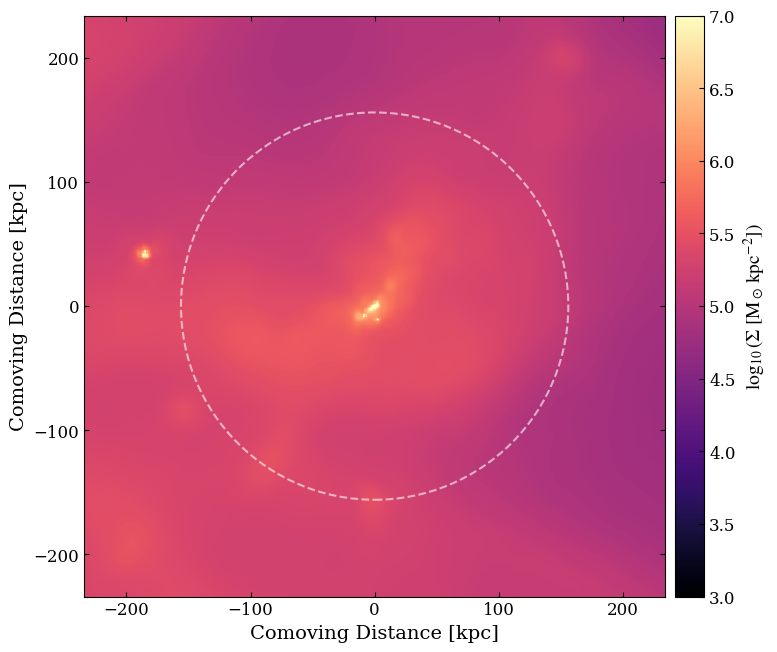

In [ ]:

plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True 


gas_map = sg_img(sg)
gas_map_value = gas_map.value.T 

# warnings with log10(0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gas_map_log = np.log10(gas_map_value)


gas_map_masked_unaligned = np.ma.masked_invalid(gas_map_log)


cmap = plt.cm.magma.copy()
cmap.set_bad('white')   
cmap.set_under('white')


fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    gas_map_masked_unaligned,
    origin='lower',
    cmap=cmap,
    vmin=3,   
    vmax=7,   
    extent=im_region,
    aspect='equal',         
    interpolation='nearest' 
)

# Extract R_200 from  SWIFTGalaxy object
r200_kpc = sg.halo_catalogue.spherical_overdensity_200_crit.soradius.to('kpc').value

circle = plt.Circle((0, 0), radius=r200_kpc, color='white', 
                    fill=False, linestyle='--', alpha=0.6, linewidth=1.5)
ax.add_patch(circle)


ax.set_xlabel('Comoving Distance [kpc]', fontsize=14)
ax.set_ylabel('Comoving Distance [kpc]', fontsize=14)

#
ax.tick_params(axis='both', which='both', direction='in', 
               top=True, right=True, labelsize=12)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)


cbar.set_label(r'$\log_{10}(\Sigma \,\, [\mathrm{M}_\odot \, \mathrm{kpc}^{-2}])$', fontsize=14)
cbar.ax.tick_params(labelsize=12, direction='in')


plt.show()

## Projection of aligned gas envelope

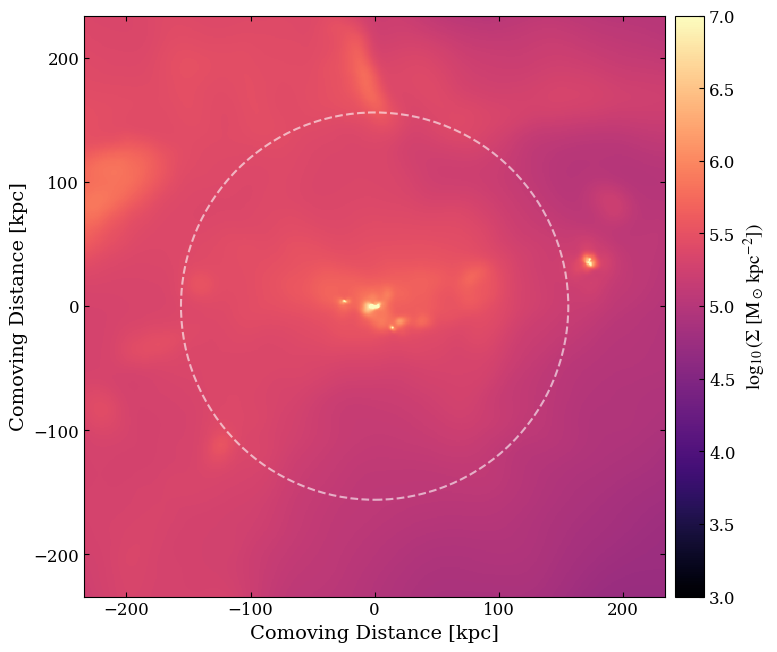

In [ ]:
mask_edge_on_disk(sg)
gas_map = sg_img(sg)
gas_map_value = gas_map.value.T 


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gas_map_log = np.log10(gas_map_value)


gas_map_masked_aligned = np.ma.masked_invalid(gas_map_log)


cmap = plt.cm.magma.copy()
cmap.set_bad('white')   
cmap.set_under('white') 

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    gas_map_masked_aligned,
    origin='lower',
    cmap=cmap,
    vmin=3,   
    vmax=7,   
    extent=im_region,
    aspect='equal',         
    interpolation='nearest' 
)



r200_kpc = sg.halo_catalogue.spherical_overdensity_200_crit.soradius.to('kpc').value

circle = plt.Circle((0, 0), radius=r200_kpc, color='white', 
                    fill=False, linestyle='--', alpha=0.6, linewidth=1.5)
ax.add_patch(circle)


ax.set_xlabel('Comoving Distance [kpc]', fontsize=14)
ax.set_ylabel('Comoving Distance [kpc]', fontsize=14)

ax.tick_params(axis='both', which='both', direction='in', 
               top=True, right=True, labelsize=12)


divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)


cbar.set_label(r'$\log_{10}(\Sigma \,\, [\mathrm{M}_\odot \, \mathrm{kpc}^{-2}])$', fontsize=14)
cbar.ax.tick_params(labelsize=12, direction='in')




plt.show()

### Projection of aligned and masked halo

In [ ]:
mask_edge_on(sg)
gas_map = sg_img(sg)
gas_map_value = gas_map.value.T 


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gas_map_log = np.log10(gas_map_value)

gas_map_cgm = np.ma.masked_invalid(gas_map_log)

/users/aritbick/jupyter_project/swift-env/lib/python3.12/site-packages/swiftsimio/_array_functions.py:718: RuntimeWarning: Mixing arguments with and without cosmo_factors, continuing assuming provided cosmo_factor (a**0.0 at a=0.9999999999999997) for all arguments.
  warnings.warn(


### A diagram of the isolated CGM and marking the minor and major axes for clarity

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1748356/18228437.py:50: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Comoving Distance $\mathbf{x^{\prime}} $ $[ckpc]$', fontsize=14)
/tmp/ipykernel_1748356/18228437.py:51: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Comoving Distance $\mathbf{z^{\prime}} $ $[ckpc]$', fontsize=14)


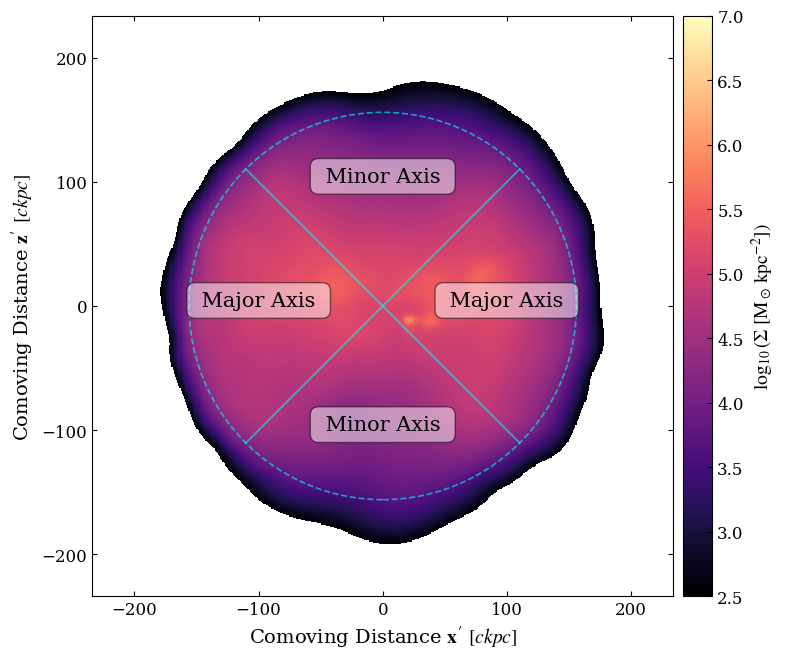

In [ ]:


cmap = plt.cm.magma.copy()
cmap.set_bad('white')   
cmap.set_under('white') 


fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    gas_map_cgm,
    origin='lower',
    cmap=cmap,
    vmin=2.5,   
    vmax=7,   
    extent=im_region,
    aspect='equal',         
    interpolation='nearest' 
)



r200_kpc = sg.halo_catalogue.spherical_overdensity_200_crit.soradius.to('kpc').value

ann_params = dict(color='cyan', alpha=0.6, linewidth=1.2, zorder=3)


circle = plt.Circle((0, 0), radius=r200_kpc, fill=False, 
                    linestyle='--', **ann_params)
ax.add_patch(circle)


d = r200_kpc / np.sqrt(2)


ax.plot([-d, d], [-d, d], linestyle='-', **ann_params)


ax.plot([-d, d], [d, -d], linestyle='-', **ann_params)

ax.set_xlabel('Comoving Distance $\mathbf{x^{\prime}} $ $[ckpc]$', fontsize=14)
ax.set_ylabel('Comoving Distance $\mathbf{z^{\prime}} $ $[ckpc]$', fontsize=14)


ax.tick_params(axis='both', which='both', direction='in', 
               top=True, right=True, labelsize=12)

ax.text(0, 100, r' Minor Axis ', color='black', fontsize=15, ha='center', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.5, edgecolor='black',linewidth=1))
ax.text(0, -100, r' Minor Axis ', color='black', fontsize=15, ha='center', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.5, edgecolor='black',linewidth=1))
ax.text(100, 0, r' Major Axis ', color='black', fontsize=15, ha='center', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.5, edgecolor='black',linewidth=1))
ax.text(-100, 0, r' Major Axis ', color='black', fontsize=15, ha='center', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.5, edgecolor='black',linewidth=1))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)


cbar.set_label(r'$\log_{10}(\Sigma \,\, [\mathrm{M}_\odot \, \mathrm{kpc}^{-2}])$', fontsize=14)
cbar.ax.tick_params(labelsize=12, direction='in')




plt.show()

### Create a panel of all three plots to give the reader a nice idea

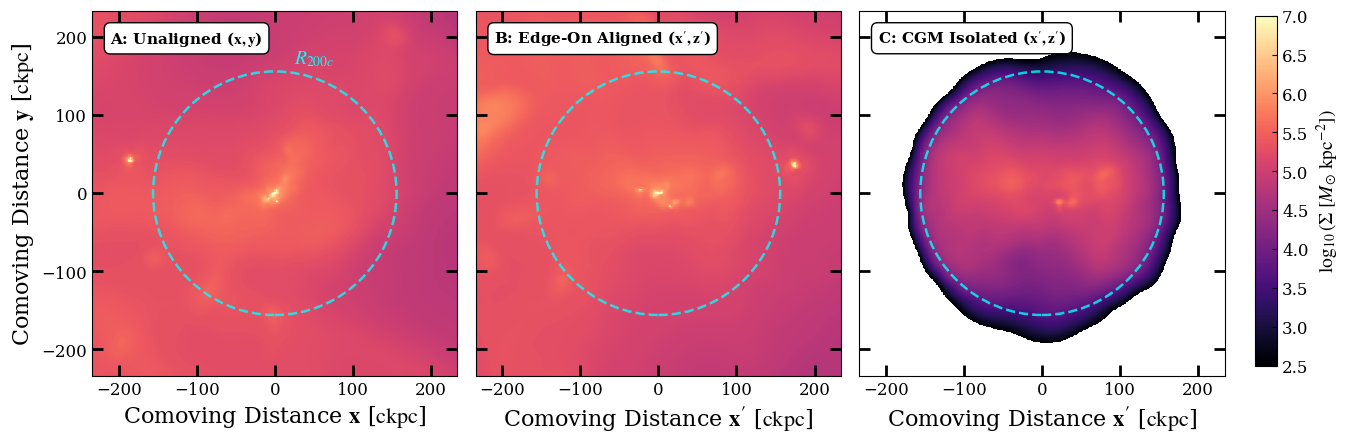

In [ ]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
#

data_list = [gas_map_masked_unaligned, gas_map_masked_aligned, gas_map_cgm]
box_labels = [
    r'A: Unaligned ($\mathbf{x, y}$)', 
    r'B: Edge-On Aligned ($\mathbf{x^{\prime}, z^{\prime}}$)', 
    r'C: CGM Isolated ($\mathbf{x^{\prime}, z^{\prime}}$)'
]


cmap = plt.cm.magma.copy()
cmap.set_bad('white')   
cmap.set_under('white')


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Adjustments to colour scale 
vmin, vmax = 2.5, 7.0

for i, ax in enumerate(axes):
    data = data_list[i].copy()
    data[~np.isfinite(data)] = np.nan
    
    im = ax.imshow(data, origin='lower', extent=im_region,
                   cmap=cmap, vmin=vmin, vmax=vmax, 
                   aspect='equal', interpolation='nearest')
    
    circle = plt.Circle((0, 0), radius=r200_kpc, color='cyan', 
                        fill=False, linestyle='--', alpha=0.8, linewidth=1.8)
    ax.add_patch(circle)

    
    ax.text(0.05, 0.95, box_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1.0, edgecolor='black',linewidth=1))
    
    label_style = {'fontsize': 14, 'fontweight': 'bold', 'labelpad': 10}

    
    if i == 0:
        
        ax.set_xlabel(r'Comoving Distance $\mathbf{x}$ [$\mathrm{ckpc}$]', fontsize=16)
        ax.set_ylabel(r'Comoving Distance $\mathbf{y}$ [$\mathrm{ckpc}$]', fontsize=16)
        ax.text(50, r200_kpc + 10, r'$R_{200c}$', color='cyan', fontsize=14, ha='center')
    else:
        #
        ax.set_xlabel(r'Comoving Distance $\mathbf{x^{\prime}}$ [$\mathrm{ckpc}$]', fontsize=16)
        

    ax.tick_params(axis='both', which='major', labelsize=12, 
                   direction='in', length=8, width=2, 
                   top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   length=4, width=1.5, top=True, right=True)


fig.subplots_adjust(right=0.88, wspace=0.05) 
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7]) 
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\log_{10} (\Sigma \ [M_{\odot} \ \mathrm{kpc}^{-2}])$',fontsize=14)

plt.savefig('galactic_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()

### Zoomed images of the aligned disk


These didn't quite make it into the report

In [ ]:
def mask_face_on(sg):
    r200 = sg.halo_catalogue.spherical_overdensity_200_crit.soradius
    ang_mom_vec = sg.halo_catalogue.exclusive_sphere_10kpc.angular_momentum_stars
    mask = MaskCollection(
        #gas=sg.gas.spherical_coordinates.r < 50. * u.kpc, ##Change back to 50
        gas=sg.gas.spherical_coordinates.r < r200,
    )

    sg.mask_particles(mask)

    # Define a new coordinate system from the angular momentum vector
    ang_mom_vec = ang_mom_vec.squeeze()

    zhat = (ang_mom_vec / np.sqrt(np.sum(ang_mom_vec**2))).to_value(u.dimensionless)  # we'll align L with the z-axis

    arb = np.ones(3) / np.sqrt(3)  # Take an arbitrary vector
    xvec = arb - arb.dot(zhat) * zhat # Make it orthogonal to zhat
    xhat = xvec / np.sqrt(np.sum(xvec**2)) # normalise it

    yhat = np.cross(zhat, xhat)  # Get the unit vector orthogonal to both xhat and zhat

    rotmat = np.vstack((xhat, yhat, zhat)).T ##Face On
 
    sg.rotate(Rotation.from_matrix(rotmat))

def mask_edge_on_disk(sg):

    r200 = sg.halo_catalogue.spherical_overdensity_200_crit.soradius
    ang_mom_vec = sg.halo_catalogue.exclusive_sphere_10kpc.angular_momentum_stars
    
    #mask = MaskCollection(
        #gas=sg.gas.spherical_coordinates.r < 50. * u.kpc, ##Change back to 50
        #gas=sg.gas.spherical_coordinates.r < r200,
    #)

    #sg.mask_particles(mask)

    # Define a new coordinate system from the angular momentum vector
    ang_mom_vec = ang_mom_vec.squeeze()

    zhat = (ang_mom_vec / np.sqrt(np.sum(ang_mom_vec**2))).to_value(u.dimensionless)  # we'll align L with the z-axis

    arb = np.ones(3) / np.sqrt(3)  # Take an arbitrary vector
    xvec = arb - arb.dot(zhat) * zhat # Make it orthogonal to zhat
    xhat = xvec / np.sqrt(np.sum(xvec**2)) # normalise it

    yhat = np.cross(zhat, xhat)  # Get the unit vector orthogonal to both xhat and zhat

    
    #rotmat = np.vstack((-zhat, yhat, xhat)).T ##Edge-on upwards
    rotmat = np.vstack((xhat, -zhat, yhat)).T ##Edge-on sidewards

    sg.rotate(Rotation.from_matrix(rotmat))


In [103]:
mask_face_on(sg)
disk_img = project_gas(
    sg,
    resolution=512,
    region=sw.cosmo_array(
        [-30, 30, -30, 30],
        u.kpc,
        comoving=True,
        scale_factor=sg.metadata.a,
        scale_exponent=1
    ),
    project='masses',
    parallel=False,
    periodic=True,

)

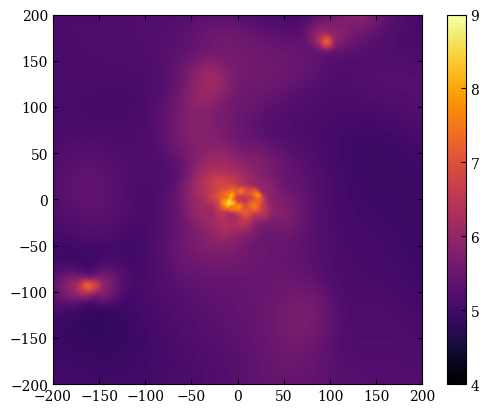

In [117]:
plt.imshow(np.log10(disk_img.T), origin='lower',extent=[-200, 200, -200, 200], cmap='inferno',vmin=4.0,vmax=9)
plt.colorbar()

In [121]:
mask_edge_on_disk(sg)
disk_img = project_gas(
    sg,
    resolution=512,
    region=sw.cosmo_array(
        [-30, 30, -30, 30],
        u.kpc,
        comoving=True,
        scale_factor=sg.metadata.a,
        scale_exponent=1
    ),
    project='masses',
    parallel=False,
    periodic=True,

)

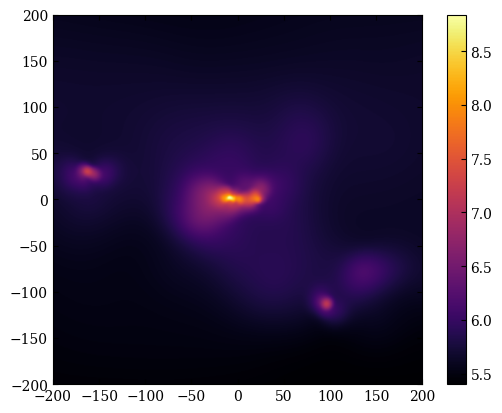

In [133]:
plt.imshow(np.log10(disk_img.T), origin='lower',extent=[-200, 200, -200, 200], cmap='inferno')
plt.colorbar()